# Cardiovascular Disease Prediction using Deep Learning

## Overview

This notebook implements three deep learning models to classify the presence of cardiovascular disease (CVD) from patient health records. The dataset contains 70,000 patient records with 11 raw clinical features. Six additional features are derived through domain-informed feature engineering, bringing the total to 17.

## Dataset

**Source:** `cardio_train.csv` — 70,000 records, binary target (`cardio`: 0 = no CVD, 1 = CVD present)

**Raw features:** age, gender, height, weight, systolic BP (`ap_hi`), diastolic BP (`ap_lo`), cholesterol, glucose, smoking, alcohol consumption, physical activity

## Models Implemented

| Model | Architecture | Role |
|-------|-------------|------|
| Logistic Regression | Single linear layer + sigmoid | Interpretable baseline |
| Fully-Connected Neural Network (MLP) | 4 hidden layers with BatchNorm & Dropout | Primary classifier |
| Autoencoder + Classifier | Encoder–decoder with classifier head | Representation learning |

## Engineered Features

| Feature | Formula | Rationale |
|---------|---------|----------|
| `bmi` | weight / (height/100)² | Body Mass Index — established obesity metric |
| `pulse_pressure` | ap_hi − ap_lo | Indicator of arterial stiffness |
| `map` | ap_lo + pulse_pressure/3 | Mean arterial pressure — average circulatory load |
| `age_group` | binned age (decades) | Captures non-linear age-related CVD risk |
| `hypertension` | ap_hi ≥ 140 or ap_lo ≥ 90 | Binary flag per ESC/ESH clinical guidelines |
| `obese` | bmi ≥ 30 | Binary flag per WHO obesity definition |

## 0. Libraries and Reproducibility

All required libraries are imported below. A fixed random seed is set for both PyTorch and NumPy to ensure reproducibility of results across runs.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.11.0+cpu
Device: CPU


## 1. Data Loading and Cleaning

The dataset is loaded from a semicolon-delimited CSV file. Three preprocessing steps are applied:

1. **Age conversion** — raw values are stored in days and converted to years for interpretability.
2. **ID removal** — the `id` column is a row identifier with no predictive value and is dropped.
3. **Blood pressure outlier removal** — physiologically implausible values are removed (systolic BP outside 80–200 mmHg; diastolic BP outside 40–150 mmHg). These represent data entry errors.

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")
print("Raw shape:", df.shape)
df.head()

Raw shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Convert age from days → years
df["age"] = df["age"] / 365

# Drop ID
df = df.drop(columns=["id"])

# Remove blood pressure outliers
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 200)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 150)]

print(f"After cleaning: {df.shape}")

After cleaning: (68687, 12)


## 2. Feature Engineering

Six clinically-motivated features are derived from the raw data. These transformations encode domain knowledge about cardiovascular risk that is difficult for a model to learn implicitly from raw values alone. For example, BMI and pulse pressure are established biomarkers used in clinical CVD risk assessment.

All engineered features are applied consistently during both training and inference to prevent data leakage.

In [4]:
# BMI — weight relative to height (strong CVD predictor)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Pulse pressure — difference between systolic and diastolic BP
# High values indicate arterial stiffness
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

# Mean arterial pressure — overall circulatory load on the heart
df["map"] = df["ap_lo"] + (df["pulse_pressure"] / 3)

# Age groups — CVD risk increases non-linearly with age
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 50, 55, 60, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Hypertension flag — clinically defined threshold (ESC/ESH guidelines)
df["hypertension"] = ((df["ap_hi"] >= 140) | (df["ap_lo"] >= 90)).astype(int)

# Obesity flag — WHO definition
df["obese"] = (df["bmi"] >= 30).astype(int)

print(f"Features after engineering: {df.drop(columns=['cardio']).shape[1]}")
print("\nNew feature stats:")
print(df[["bmi", "pulse_pressure", "map", "hypertension", "obese"]].describe().round(2))

Features after engineering: 17

New feature stats:
            bmi  pulse_pressure       map  hypertension     obese
count  68687.00        68687.00  68687.00      68687.00  68687.00
mean      27.52           45.23     96.40          0.34      0.26
std        6.05           11.91     10.94          0.47      0.44
min        3.47          -60.00     53.33          0.00      0.00
25%       23.88           40.00     93.33          0.00      0.00
50%       26.35           40.00     93.33          0.00      0.00
75%       30.12           50.00    103.33          1.00      1.00
max      298.67          135.00    160.00          1.00      1.00


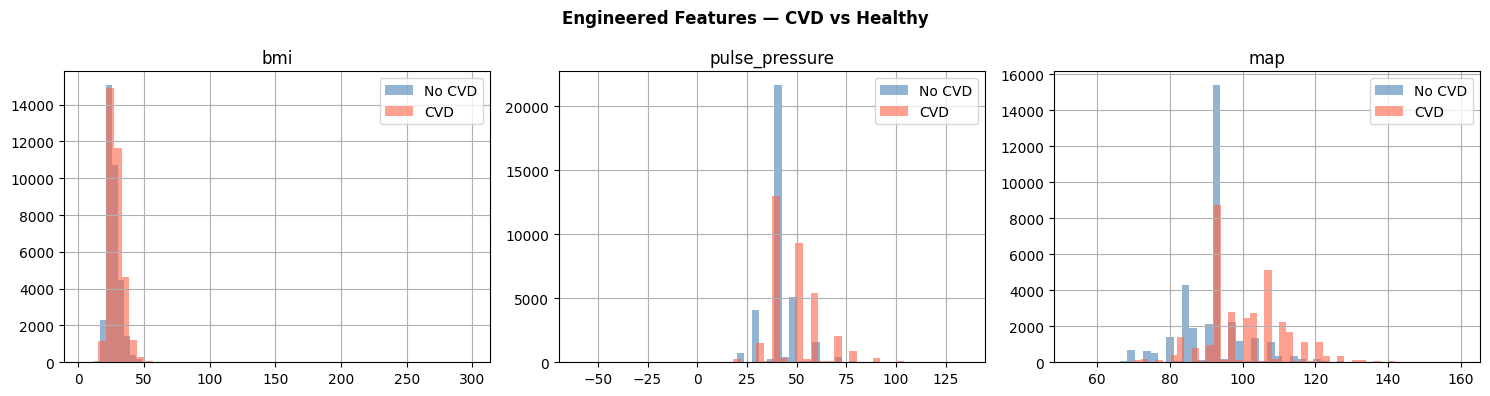

In [5]:
# Visualise new features by CVD status
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ["bmi", "pulse_pressure", "map"]):
    df[df["cardio"] == 0][feat].hist(ax=ax, bins=50, alpha=0.6, label="No CVD", color="steelblue")
    df[df["cardio"] == 1][feat].hist(ax=ax, bins=50, alpha=0.6, label="CVD",    color="tomato")
    ax.set_title(feat)
    ax.legend()

plt.suptitle("Engineered Features — CVD vs Healthy", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Data Splitting and Normalisation

The dataset is partitioned into three non-overlapping sets:
- **Training set (70%)** — used to fit model parameters.
- **Validation set (15%)** — used to monitor generalisation during training and tune hyperparameters.
- **Test set (15%)** — held out entirely until final evaluation to provide an unbiased performance estimate.

Feature standardisation (`StandardScaler`) is applied to bring all features to zero mean and unit variance. The scaler is fitted exclusively on the training set and then applied to validation and test sets to prevent data leakage.

In [6]:
X = df.drop(columns=["cardio"]).values
y = df["cardio"].values
feature_names = df.drop(columns=["cardio"]).columns.tolist()
print("Features:", feature_names)

# Train / Val / Test: 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))

X_tr, y_tr = to_tensors(X_train, y_train)
X_vl, y_vl = to_tensors(X_val,   y_val)
X_ts, y_ts = to_tensors(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=256)
test_loader  = DataLoader(TensorDataset(X_ts, y_ts), batch_size=256)

INPUT_DIM = X_train.shape[1]
print(f"\nInput features : {INPUT_DIM}")
print(f"Train samples  : {len(X_tr)}")
print(f"Val samples    : {len(X_vl)}")
print(f"Test samples   : {len(X_ts)}")

Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'map', 'age_group', 'hypertension', 'obese']

Input features : 17
Train samples  : 48080
Val samples    : 10303
Test samples   : 10304


## 4. Training and Evaluation Utilities

Two reusable functions are defined here and shared across all three models:

- **`train_model`** — runs the training loop for a specified number of epochs, computing training loss and validation loss/accuracy at each epoch.
- **`evaluate_model`** — evaluates a trained model on the test set and reports accuracy, ROC-AUC, and a full classification report. The `is_autoencoder` flag handles the tuple output of the Autoencoder model.
- **`plot_curves`** — plots training/validation loss and validation accuracy over epochs to visualise convergence behaviour.

In [7]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                epochs=30, model_name="Model"):
    train_losses, val_losses, val_accs = [], [], []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch).squeeze()
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds     = model(X_batch).squeeze()
                val_loss += criterion(preds, y_batch).item()
                predicted = (preds >= 0.5).float()
                correct  += (predicted == y_batch).sum().item()
                total    += y_batch.size(0)

        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        if epoch % 10 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f} | "
                  f"Val Acc: {val_accs[-1]:.4f}")
    return train_losses, val_losses, val_accs


def evaluate_model(model, test_loader, model_name="Model", is_autoencoder=False):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            probs  = output[0].squeeze() if is_autoencoder else output.squeeze()
            preds  = (probs >= 0.5).float()
            all_probs.extend(probs.numpy())
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["No CVD", "CVD"]))
    return acc, auc


def plot_curves(name, train_losses, val_losses, val_accs):
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax2 = ax1.twinx()
    epochs_range = range(1, len(train_losses) + 1)
    ax1.plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
    ax1.plot(epochs_range, val_losses,   label="Val Loss",   color="tomato",   linestyle="--")
    ax2.plot(epochs_range, val_accs,     label="Val Acc",    color="seagreen", linestyle=":")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.set_title(f"{name} — Training Curves")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()

## 5. Model 1 — Logistic Regression

**Architecture:** A single fully-connected linear layer followed by a sigmoid activation function. This is the simplest form of binary classifier and serves as an interpretable baseline.

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

**Loss function:** Binary Cross-Entropy (BCE)

**Optimiser:** Adam with L2 weight decay (`weight_decay=1e-3`) to penalise large weights and reduce overfitting.

**Interpretability:** The learned weights directly indicate the direction and magnitude of each feature's influence on the CVD prediction. Positive weights increase predicted risk; negative weights reduce it.

In [8]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


lr_model = LogisticRegressionModel(INPUT_DIM)
lr_optim = torch.optim.Adam(lr_model.parameters(), lr=0.0005, weight_decay=1e-3)
lr_crit  = nn.BCELoss()

print(lr_model)
print(f"Total parameters: {sum(p.numel() for p in lr_model.parameters())}")

LogisticRegressionModel(
  (linear): Linear(in_features=17, out_features=1, bias=True)
)
Total parameters: 18


In [9]:
lr_train_losses, lr_val_losses, lr_val_accs = train_model(
    lr_model, train_loader, val_loader, lr_optim, lr_crit,
    epochs=50, model_name="LogReg"
)

[LogReg] Epoch   1/50 | Train Loss: 0.6277 | Val Loss: 0.6041 | Val Acc: 0.6798
[LogReg] Epoch  10/50 | Train Loss: 0.5559 | Val Loss: 0.5599 | Val Acc: 0.7260
[LogReg] Epoch  20/50 | Train Loss: 0.5552 | Val Loss: 0.5593 | Val Acc: 0.7276
[LogReg] Epoch  30/50 | Train Loss: 0.5552 | Val Loss: 0.5593 | Val Acc: 0.7267
[LogReg] Epoch  40/50 | Train Loss: 0.5552 | Val Loss: 0.5593 | Val Acc: 0.7264
[LogReg] Epoch  50/50 | Train Loss: 0.5552 | Val Loss: 0.5593 | Val Acc: 0.7268



  Logistic Regression — Test Results
  Accuracy : 0.7241
  ROC-AUC  : 0.7910
              precision    recall  f1-score   support

      No CVD       0.69      0.80      0.74      5155
         CVD       0.76      0.65      0.70      5149

    accuracy                           0.72     10304
   macro avg       0.73      0.72      0.72     10304
weighted avg       0.73      0.72      0.72     10304



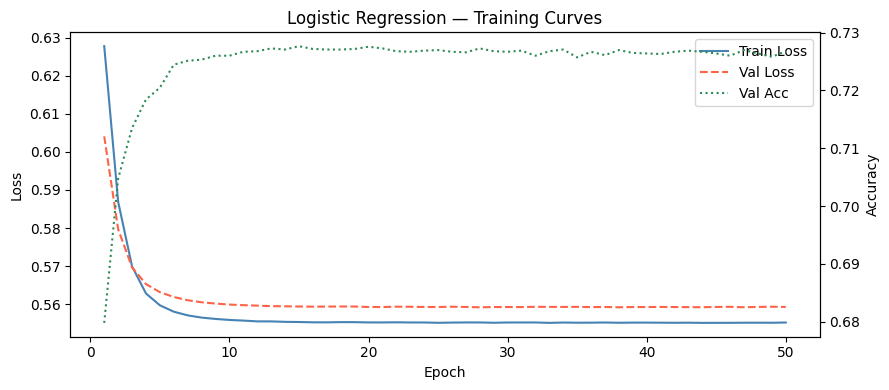

In [10]:
lr_acc, lr_auc = evaluate_model(lr_model, test_loader, "Logistic Regression")
plot_curves("Logistic Regression", lr_train_losses, lr_val_losses, lr_val_accs)

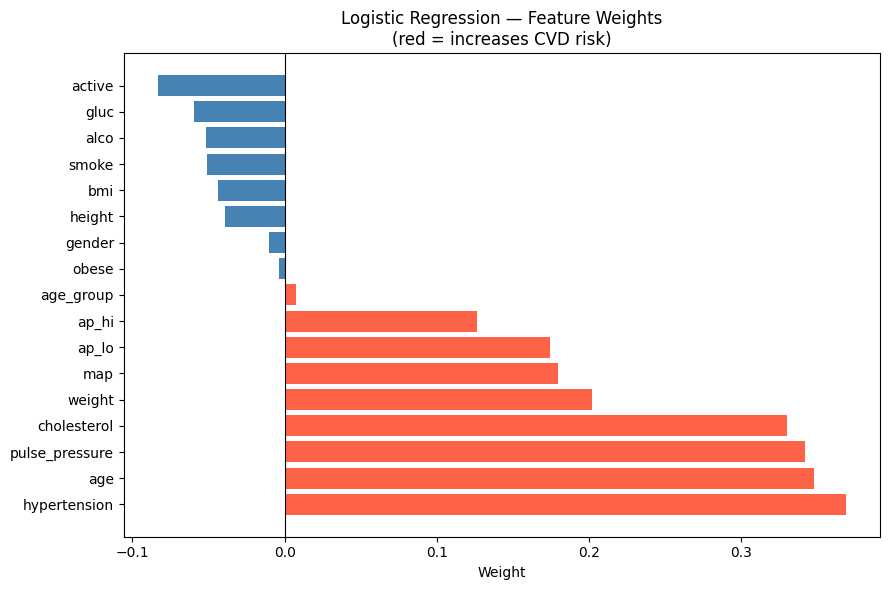

In [11]:
weights = lr_model.linear.weight.data.squeeze().numpy()
sorted_feats   = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)
names_sorted   = [f[0] for f in sorted_feats]
weights_sorted = [f[1] for f in sorted_feats]
colors = ["tomato" if w > 0 else "steelblue" for w in weights_sorted]

plt.figure(figsize=(9, 6))
plt.barh(names_sorted, weights_sorted, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weight")
plt.title("Logistic Regression — Feature Weights\n(red = increases CVD risk)")
plt.tight_layout()
plt.show()

## 6. Model 2 — Fully-Connected Neural Network (MLP)

**Architecture:** A multi-layer perceptron with four hidden layers of decreasing width (256 → 128 → 64 → 32), followed by a sigmoid output.

Each hidden layer applies the following sequence:
```
Linear → BatchNorm → ReLU → Dropout
```

**Regularisation techniques applied:**
- **Batch Normalisation** — normalises activations within each mini-batch, stabilising training and reducing internal covariate shift.
- **Dropout (p=0.2)** — randomly deactivates 20% of neurons per forward pass during training to prevent co-adaptation and overfitting.
- **L2 Weight Decay** — applied via the Adam optimiser (`weight_decay=1e-4`).

**Learning rate schedule:** `CosineAnnealingLR` gradually reduces the learning rate following a cosine curve over 60 epochs, allowing fine-grained convergence in later training stages.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


mlp_model = MLP(INPUT_DIM)
mlp_optim = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
mlp_crit  = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(mlp_optim, T_max=60)

print(mlp_model)
print(f"Total parameters: {sum(p.numel() for p in mlp_model.parameters())}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
    (17): Sigmoid()
  )
)
Total parameters: 48833


In [13]:
mlp_train_losses, mlp_val_losses, mlp_val_accs = [], [], []

for epoch in range(1, 61):
    mlp_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        mlp_optim.zero_grad()
        loss = mlp_crit(mlp_model(X_batch).squeeze(), y_batch)
        loss.backward()
        mlp_optim.step()
        ep_loss += loss.item()
    scheduler.step()

    mlp_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds     = mlp_model(X_batch).squeeze()
            val_loss += mlp_crit(preds, y_batch).item()
            correct  += ((preds >= 0.5).float() == y_batch).sum().item()
            total    += y_batch.size(0)

    mlp_train_losses.append(ep_loss / len(train_loader))
    mlp_val_losses.append(val_loss / len(val_loader))
    mlp_val_accs.append(correct / total)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[MLP] Epoch {epoch:3d}/60 | Train Loss: {mlp_train_losses[-1]:.4f} | "
              f"Val Loss: {mlp_val_losses[-1]:.4f} | Val Acc: {mlp_val_accs[-1]:.4f}")

[MLP] Epoch   1/60 | Train Loss: 0.5622 | Val Loss: 0.5516 | Val Acc: 0.7321
[MLP] Epoch  10/60 | Train Loss: 0.5445 | Val Loss: 0.5474 | Val Acc: 0.7332
[MLP] Epoch  20/60 | Train Loss: 0.5404 | Val Loss: 0.5459 | Val Acc: 0.7325
[MLP] Epoch  30/60 | Train Loss: 0.5379 | Val Loss: 0.5470 | Val Acc: 0.7343
[MLP] Epoch  40/60 | Train Loss: 0.5344 | Val Loss: 0.5476 | Val Acc: 0.7307
[MLP] Epoch  50/60 | Train Loss: 0.5322 | Val Loss: 0.5482 | Val Acc: 0.7333
[MLP] Epoch  60/60 | Train Loss: 0.5295 | Val Loss: 0.5481 | Val Acc: 0.7317



  MLP — Test Results
  Accuracy : 0.7319
  ROC-AUC  : 0.7985
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      5155
         CVD       0.75      0.69      0.72      5149

    accuracy                           0.73     10304
   macro avg       0.73      0.73      0.73     10304
weighted avg       0.73      0.73      0.73     10304



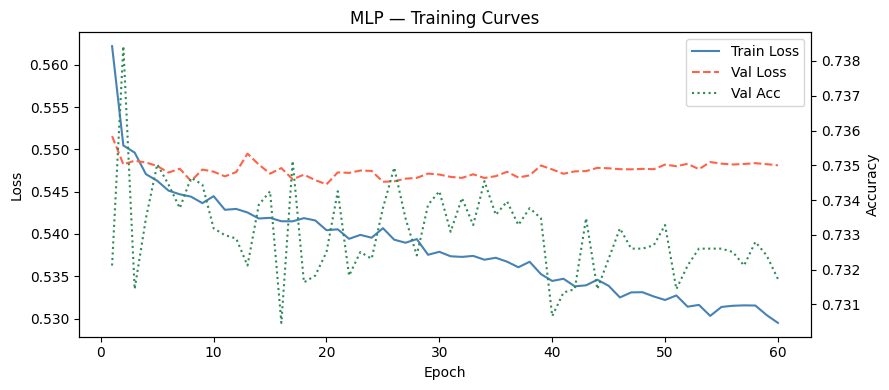

In [14]:
mlp_acc, mlp_auc = evaluate_model(mlp_model, test_loader, "MLP")
plot_curves("MLP", mlp_train_losses, mlp_val_losses, mlp_val_accs)

## 7. Model 3 — Autoencoder with Classifier Head

**Motivation:** Autoencoders learn a compressed latent representation of the input by training an encoder–decoder pair to reconstruct the original data. The latent space captures the most salient structure in the data. A classifier head is then trained on this latent representation to predict CVD.

**Architecture:**
```
Input (17) ──► Encoder ──► Latent Space (16) ──► Decoder ──► Reconstructed Input (17)
                                   │
                                   ▼
                          Classifier Head ──► CVD Probability
```

**Loss function:** A weighted combination of two terms:
```
Total Loss = BCE(classification) + 0.3 × MSE(reconstruction)
```
The reconstruction term acts as a self-supervised regulariser, encouraging the encoder to learn a general-purpose representation rather than one optimised purely for classification.

**Regularisation:** BatchNorm and Dropout (p=0.2) are applied in the classifier head. CosineAnnealingLR is used as the learning rate schedule.

In [15]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z        = self.encoder(x)
        x_recon  = self.decoder(z)
        cvd_prob = self.classifier(z)
        return cvd_prob, x_recon


ae_model = Autoencoder(INPUT_DIM, latent_dim=16)
ae_optim = torch.optim.Adam(ae_model.parameters(), lr=0.001, weight_decay=1e-4)
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()
ae_sched = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optim, T_max=60)

print(ae_model)
print(f"Total parameters: {sum(p.numel() for p in ae_model.parameters())}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=17, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
 

In [16]:
ae_train_losses, ae_val_losses, ae_val_accs = [], [], []

for epoch in range(1, 61):
    ae_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        ae_optim.zero_grad()
        cvd_prob, x_recon = ae_model(X_batch)
        cls_loss   = bce_loss(cvd_prob.squeeze(), y_batch)
        recon_loss = mse_loss(x_recon, X_batch)
        loss       = cls_loss + 0.3 * recon_loss
        loss.backward()
        ae_optim.step()
        ep_loss += loss.item()
    ae_sched.step()

    ae_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            cvd_prob, x_recon = ae_model(X_batch)
            cls_l    = bce_loss(cvd_prob.squeeze(), y_batch)
            rec_l    = mse_loss(x_recon, X_batch)
            val_loss += (cls_l + 0.3 * rec_l).item()
            preds    = (cvd_prob.squeeze() >= 0.5).float()
            correct  += (preds == y_batch).sum().item()
            total    += y_batch.size(0)

    ae_train_losses.append(ep_loss / len(train_loader))
    ae_val_losses.append(val_loss / len(val_loader))
    ae_val_accs.append(correct / total)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[AE]  Epoch {epoch:3d}/60 | Train Loss: {ae_train_losses[-1]:.4f} | "
              f"Val Loss: {ae_val_losses[-1]:.4f} | Val Acc: {ae_val_accs[-1]:.4f}")

[AE]  Epoch   1/60 | Train Loss: 0.7728 | Val Loss: 0.6754 | Val Acc: 0.7303
[AE]  Epoch  10/60 | Train Loss: 0.5624 | Val Loss: 0.5673 | Val Acc: 0.7343
[AE]  Epoch  20/60 | Train Loss: 0.5518 | Val Loss: 0.5588 | Val Acc: 0.7330
[AE]  Epoch  30/60 | Train Loss: 0.5470 | Val Loss: 0.5564 | Val Acc: 0.7327
[AE]  Epoch  40/60 | Train Loss: 0.5449 | Val Loss: 0.5561 | Val Acc: 0.7334
[AE]  Epoch  50/60 | Train Loss: 0.5426 | Val Loss: 0.5562 | Val Acc: 0.7313
[AE]  Epoch  60/60 | Train Loss: 0.5409 | Val Loss: 0.5561 | Val Acc: 0.7316



  Autoencoder — Test Results
  Accuracy : 0.7308
  ROC-AUC  : 0.7989
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      5155
         CVD       0.76      0.68      0.72      5149

    accuracy                           0.73     10304
   macro avg       0.73      0.73      0.73     10304
weighted avg       0.73      0.73      0.73     10304



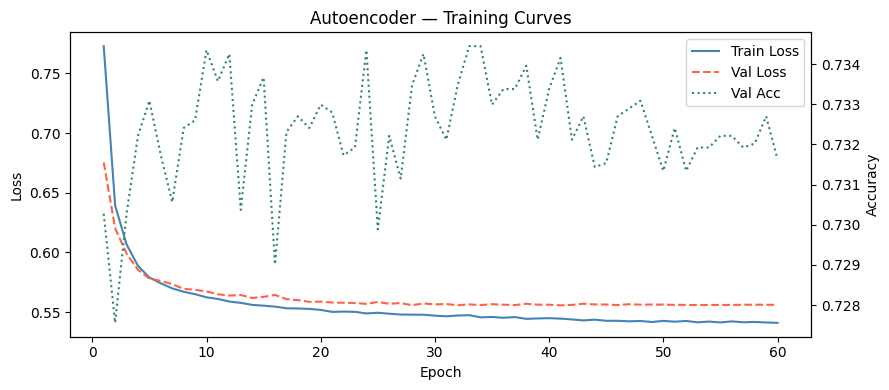

In [17]:
ae_acc, ae_auc = evaluate_model(ae_model, test_loader, "Autoencoder", is_autoencoder=True)
plot_curves("Autoencoder", ae_train_losses, ae_val_losses, ae_val_accs)

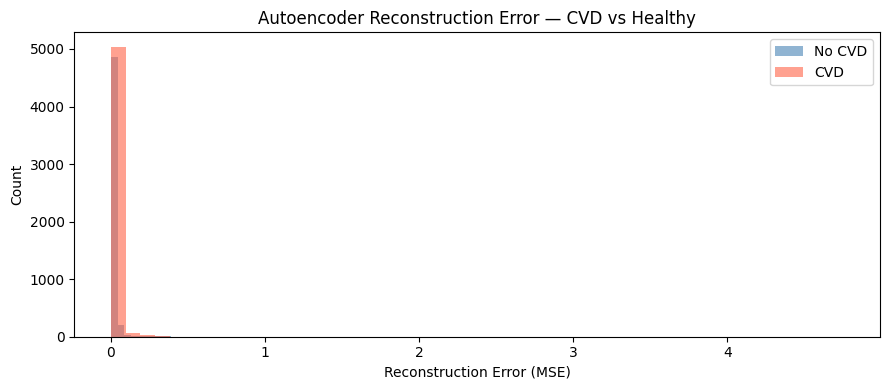

Mean recon error — Healthy : 0.0166
Mean recon error — CVD     : 0.0212


In [18]:
# Reconstruction error distribution: CVD vs healthy
ae_model.eval()
recon_errors_cvd, recon_errors_healthy = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        _, x_recon = ae_model(X_batch)
        errors = ((x_recon - X_batch) ** 2).mean(dim=1).numpy()
        for err, label in zip(errors, y_batch.numpy()):
            (recon_errors_cvd if label == 1 else recon_errors_healthy).append(err)

plt.figure(figsize=(9, 4))
plt.hist(recon_errors_healthy, bins=50, alpha=0.6, label="No CVD", color="steelblue")
plt.hist(recon_errors_cvd,     bins=50, alpha=0.6, label="CVD",    color="tomato")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error — CVD vs Healthy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean recon error — Healthy : {np.mean(recon_errors_healthy):.4f}")
print(f"Mean recon error — CVD     : {np.mean(recon_errors_cvd):.4f}")

## 8. Model Comparison

The three models are evaluated on the held-out test set using two metrics:

- **Accuracy** — proportion of correctly classified samples.
- **ROC-AUC** — area under the receiver operating characteristic curve; measures the model's ability to rank positive cases above negative ones regardless of threshold. A value of 1.0 is perfect; 0.5 is random.

The bar chart below provides a direct visual comparison across models.

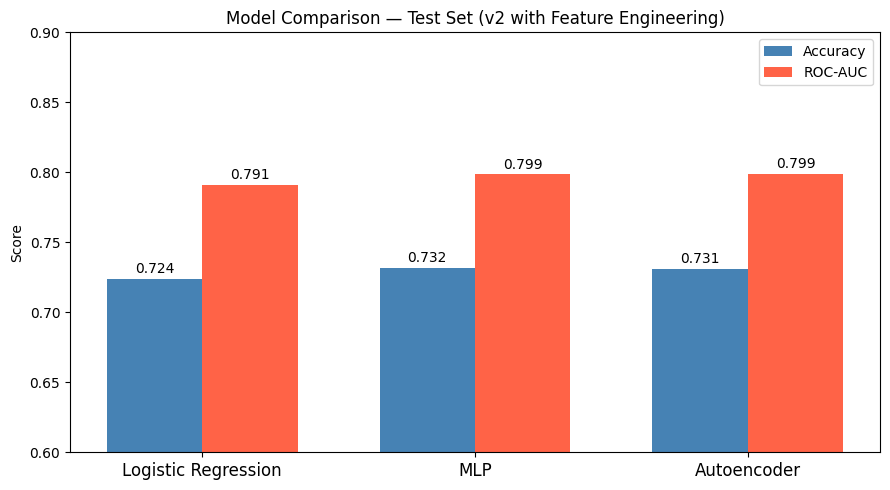


Final Summary:
Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           0.7241     0.7910
MLP                           0.7319     0.7985
Autoencoder                   0.7308     0.7989


In [19]:
model_names = ["Logistic Regression", "MLP", "Autoencoder"]
accuracies  = [lr_acc, mlp_acc, ae_acc]
aucs        = [lr_auc, mlp_auc, ae_auc]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(model_names))
w = 0.35

bars1 = ax.bar(x - w/2, accuracies, w, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + w/2, aucs,       w, label="ROC-AUC",  color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0.6, 0.9)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set (v2 with Feature Engineering)")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("\nFinal Summary:")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
for name, acc, auc in zip(model_names, accuracies, aucs):
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f}")

## 9. Prediction

Two prediction modes are demonstrated below:

1. **Single patient prediction** — accepts raw clinical values for an individual patient, applies feature engineering and normalisation, and outputs CVD probability and risk classification from all three models.
2. **Batch prediction on the test set** — runs all three models over the full test set and saves results to CSV files, including true labels, predicted labels, predicted probabilities, and a correctness flag.

### 9.1 Single Patient Prediction

The function below accepts a dictionary of raw patient values (as would be collected during a clinical assessment), applies the same feature engineering pipeline used during training, standardises the input using the fitted scaler, and returns the CVD probability from each model.

Edit the `patient` dictionary below to test different clinical profiles.

In [24]:
# ── Single Patient Prediction ─────────────────────────────────────────────────

def predict_patient(model, scaler, patient_dict, is_autoencoder=False):
    """
    Predict CVD risk for a single patient.
    Pass raw values — feature engineering is applied automatically.
    """
    # Build base dataframe
    p = pd.DataFrame([patient_dict])

    # Apply same feature engineering as training
    p["bmi"]            = p["weight"] / ((p["height"] / 100) ** 2)
    p["pulse_pressure"] = p["ap_hi"] - p["ap_lo"]
    p["map"]            = p["ap_lo"] + (p["pulse_pressure"] / 3)
    p["age_group"]      = pd.cut(p["age"], bins=[0, 40, 50, 55, 60, 100],
                                  labels=[0, 1, 2, 3, 4]).astype(int)
    p["hypertension"]   = ((p["ap_hi"] >= 140) | (p["ap_lo"] >= 90)).astype(int)
    p["obese"]          = (p["bmi"] >= 30).astype(int)

    # Scale using the fitted scaler
    X_patient = scaler.transform(p[feature_names].values)
    X_tensor  = torch.tensor(X_patient, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        output = model(X_tensor)
        prob   = output[0].squeeze().item() if is_autoencoder else output.squeeze().item()

    risk_pct = prob * 100
    label    = "HIGH RISK ⚠️" if prob >= 0.5 else "LOW RISK ✅"
    print(f"\n{'='*45}")
    print(f"  CVD Prediction Result")
    print(f"{'='*45}")
    print(f"  Probability of CVD : {risk_pct:.1f}%")
    print(f"  Assessment         : {label}")
    print(f"{'='*45}")
    return prob


# Example patient — edit these values as needed
patient = {
    "age"         : 25,       # years
    "gender"      : 1,        # 1 = female, 2 = male
    "height"      : 170,      # cm
    "weight"      : 65.0,     # kg
    "ap_hi"       : 125,      # systolic BP
    "ap_lo"       : 75,       # diastolic BP
    "cholesterol" : 1,        # 1=normal, 2=above normal, 3=well above normal
    "gluc"        : 3,        # 1=normal, 2=above normal, 3=well above normal
    "smoke"       : 1,        # 0=no, 1=yes
    "alco"        : 1,        # 0=no, 1=yes
    "active"      : 1,        # 0=no, 1=yes
}

print("── Logistic Regression ──")
predict_patient(lr_model, scaler, patient)

print("\n── MLP ──")
predict_patient(mlp_model, scaler, patient)

print("\n── Autoencoder ──")
predict_patient(ae_model, scaler, patient, is_autoencoder=True)

── Logistic Regression ──

  CVD Prediction Result
  Probability of CVD : 6.4%
  Assessment         : LOW RISK ✅

── MLP ──

  CVD Prediction Result
  Probability of CVD : 1.9%
  Assessment         : LOW RISK ✅

── Autoencoder ──

  CVD Prediction Result
  Probability of CVD : 9.3%
  Assessment         : LOW RISK ✅


0.09281592071056366

### 9.2 Batch Prediction on the Test Set

All three models are applied to the full test set. For each sample, the predicted label (0 or 1), predicted CVD probability, and ground truth label are recorded. Results are exported to separate CSV files for further analysis.

In [25]:
# ── Batch Prediction on Test Set → CSV ───────────────────────────────────────

def predict_to_csv(model, test_loader, model_name, is_autoencoder=False):
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            probs  = output[0].squeeze() if is_autoencoder else output.squeeze()
            preds  = (probs >= 0.5).float()
            all_probs.extend(probs.numpy())
            all_preds.extend(preds.numpy())

    results = pd.DataFrame({
        "true_label"      : y_ts.numpy().astype(int),
        "predicted_label" : [int(p) for p in all_preds],
        "cvd_probability" : [round(p, 4) for p in all_probs],
        "correct"         : [int(t == p) for t, p in zip(y_ts.numpy(), all_preds)],
    })

    filename = f"predictions_{model_name.lower().replace(' ', '_')}.csv"
    results.to_csv(filename, index=False)
    print(f"[{model_name}] Saved {len(results)} predictions → {filename}")
    print(f"  Accuracy : {results['correct'].mean():.4f}")
    print(f"  CVD cases predicted: {results['predicted_label'].sum()} / {len(results)}")
    return results


results_lr  = predict_to_csv(lr_model,  test_loader, "Logistic Regression")
results_mlp = predict_to_csv(mlp_model, test_loader, "MLP")
results_ae  = predict_to_csv(ae_model,  test_loader, "Autoencoder", is_autoencoder=True)

results_lr.head()

[Logistic Regression] Saved 10304 predictions → predictions_logistic_regression.csv
  Accuracy : 0.7241
  CVD cases predicted: 4370 / 10304
[MLP] Saved 10304 predictions → predictions_mlp.csv
  Accuracy : 0.7319
  CVD cases predicted: 4699 / 10304
[Autoencoder] Saved 10304 predictions → predictions_autoencoder.csv
  Accuracy : 0.7308
  CVD cases predicted: 4615 / 10304


,true_label,predicted_label,cvd_probability,correct
0,1,1,0.8044,1
1,0,0,0.3681,1
2,1,1,0.7227,1
3,0,0,0.3375,1
4,1,1,0.8479,1


### 9.3 Inter-Model Agreement Analysis

The predictions of all three models are compared across the test set to quantify agreement. Cases where models disagree are of particular analytical interest — they typically correspond to borderline samples where the CVD probability is close to the 0.5 decision threshold, reflecting genuine uncertainty in the data rather than model error.

In [26]:
# ── Agreement between models ──────────────────────────────────────────────────

agree = (
    (results_lr["predicted_label"] == results_mlp["predicted_label"]) &
    (results_mlp["predicted_label"] == results_ae["predicted_label"])
)

print(f"All 3 models agree on  : {agree.sum()} / {len(agree)} samples ({agree.mean():.1%})")
print(f"Models disagree on     : {(~agree).sum()} samples")

# Where do they disagree?
disagreements = pd.DataFrame({
    "true"          : results_lr["true_label"],
    "logistic_reg"  : results_lr["predicted_label"],
    "mlp"           : results_mlp["predicted_label"],
    "autoencoder"   : results_ae["predicted_label"],
    "lr_prob"       : results_lr["cvd_probability"],
    "mlp_prob"      : results_mlp["cvd_probability"],
    "ae_prob"       : results_ae["cvd_probability"],
})[~agree]

print(f"\nSample of disagreements:")
disagreements.head(10)

All 3 models agree on  : 9327 / 10304 samples (90.5%)
Models disagree on     : 977 samples

Sample of disagreements:


,true,logistic_reg,mlp,autoencoder,lr_prob,mlp_prob,ae_prob
9,0,0,1,1,0.4450,0.5130,0.5616
11,0,0,1,1,0.4828,0.6178,0.6230
12,1,0,1,1,0.4256,0.5475,0.5239
21,1,0,1,0,0.4545,0.5271,0.4978
41,1,0,1,1,0.4458,0.5130,0.5791
52,1,0,1,0,0.4530,0.5116,0.4699
71,0,0,0,1,0.4716,0.4590,0.5731
73,1,0,1,1,0.3967,0.5097,0.5160
89,0,1,0,0,0.5217,0.4185,0.3822
93,1,0,1,1,0.4470,0.6641,0.6455
